# Procedural graphics generation for games
* real games need a LOT of art - sprites, textures, tiles, whole levels/maps - and hand-drawing or hand-designing every single piece of that just doesnt scale (and this whole course has never shipped a single image asset file anyway!)
* **procedural generation** means using code/randomness/algorithms to GENERATE that content instead of an artist drawing it by hand - Minecraft's entire world, roguelike dungeons, and tons of indie games lean heavily on this idea
* this lesson covers 3 classic procedural generation techniques: generating simple sprite/texture IMAGES with **Pillow**, generating a MAZE/DUNGEON layout with a real algorithm, and generating NOISE-based terrain that we turn into game-ready tile data
* lesson 27 already showed us "convert to a numpy array, then `plt.imshow()` it" for pygame Surfaces - we reuse the EXACT same trick here for Pillow Images, since we have no real game window to draw into inside this notebook

## Pillow basics - drawing images purely in code
* **Pillow** (`pip install pillow`, imported as `PIL`) is pythons classic general-purpose image library - not game-specific like pygame, but great at creating/editing/manipulating images
* `Image.new(mode, (width, height), color)` creates a blank image straight in memory, no file needed anywhere
* `ImageDraw.Draw(image)` gives us a "pen" object with a drawing vocabulary thats very similar to `pygame.draw` from lesson 27: `.rectangle()`, `.ellipse()`, `.line()`, `.polygon()`
* one important difference from pygame: PIL's shapes take a bounding box as `[x0, y0, x1, y1]` (top-left corner AND bottom-right corner), not `(x, y, width, height)` like pygame.draw.rect

In [1]:
from PIL import Image, ImageDraw  # PIL = pillow, the classic python imaging library - lets us build/draw images with pure code
import numpy as np                # we already know numpy from lesson 19/20, we need it again to turn PIL Images into arrays for display
import matplotlib.pyplot as plt   # our usual plotting tool, recap from lesson 20
import random                     # pythons built-in random module, we need it for a few "pick a random-ish value" spots below

random.seed(42)      # a fixed seed --> everyone re-running this notebook gets the EXACT same "random" textures/maze/terrain
np.random.seed(42)   # numpy has its OWN separate random generator internally, so it needs its own seed too


def show_image(pil_image, title=None, figsize=(4, 4)):
    """our little helper for this whole lesson - same idea as show_surface() from lesson 27, just for PIL Images instead of pygame Surfaces"""
    pixel_array = np.array(pil_image)  # a PIL Image isnt directly plottable - converting to a numpy array gives matplotlib something it understands
    plt.figure(figsize=figsize)
    plt.imshow(pixel_array)
    plt.axis("off")  # a generated texture doesnt need x/y axis ticks and labels
    if title:
        plt.title(title)
    plt.show()


print("pillow, numpy and matplotlib all ready to go")

pillow, numpy and matplotlib all ready to go


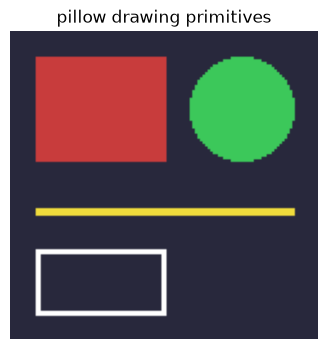

In [2]:
# Image.new(mode, (width, height), color) creates a blank image straight in memory - no file touched anywhere on disk
canvas = Image.new("RGB", (120, 120), color=(40, 40, 60))  # "RGB" mode = red/green/blue channels, same 0-255 range as pygame colors

# ImageDraw.Draw(image) gives us a "pen" object we can draw onto the image with
draw = ImageDraw.Draw(canvas)

# draw.rectangle([x0, y0, x1, y1], fill=color) - PIL uses TOP-LEFT + BOTTOM-RIGHT corners, not x/y/width/height like pygame.draw.rect
draw.rectangle([10, 10, 60, 50], fill=(200, 60, 60))

# draw.ellipse([x0, y0, x1, y1], fill=color) draws a filled ellipse INSIDE that bounding box - a perfect circle if the box is square
draw.ellipse([70, 10, 110, 50], fill=(60, 200, 90))

# draw.line([x0, y0, x1, y1], fill=color, width=...) - a straight line, width given in pixels
draw.line([10, 70, 110, 70], fill=(240, 220, 60), width=3)

# leaving out fill= and passing outline= instead draws an UNFILLED shape - just the border
draw.rectangle([10, 85, 60, 110], outline=(255, 255, 255), width=2)

show_image(canvas, title="pillow drawing primitives")

## generating simple sprite/texture images
* lets build a few reusable little "generator" functions - each one returns a brand new PIL Image built entirely out of code, no art file involved
* a gradient background tile (e.g. sky or water), a brick wall tile (repeated rectangles with randomized color so it doesnt look copy-pasted), and a simple coin/gem icon with a highlight

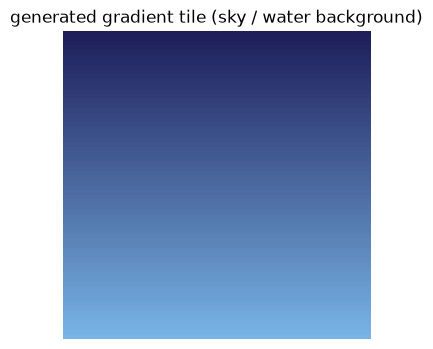

In [3]:
def make_gradient_tile(size=64, top_color=(30, 30, 90), bottom_color=(120, 180, 230)):
    """builds a simple vertical gradient tile - handy as a sky background or water texture in a game"""
    tile = Image.new("RGB", (size, size))
    pixels = tile.load()  # .load() gives us direct per-pixel access, much faster here than drawing thousands of tiny 1px lines
    for y in range(size):
        blend = y / (size - 1)  # how far down are we, as a fraction from 0.0 (top row) to 1.0 (bottom row)
        # linearly interpolate each color channel between top_color and bottom_color, based on how far down we are
        r = int(top_color[0] + (bottom_color[0] - top_color[0]) * blend)
        g = int(top_color[1] + (bottom_color[1] - top_color[1]) * blend)
        b = int(top_color[2] + (bottom_color[2] - top_color[2]) * blend)
        for x in range(size):
            pixels[x, y] = (r, g, b)  # every pixel in THIS row gets the same blended color - only y matters for a vertical gradient
    return tile


gradient_tile = make_gradient_tile()
show_image(gradient_tile, title="generated gradient tile (sky / water background)")

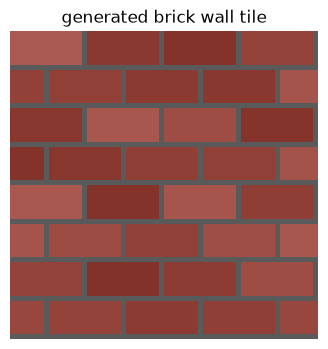

In [4]:
def make_brick_tile(size=64, brick_w=16, brick_h=8, base_color=(150, 70, 60), mortar_color=(90, 90, 90)):
    """a classic 'brick wall' texture - a grid of offset rectangles, each with a slightly randomized color for variation"""
    tile = Image.new("RGB", (size, size), color=mortar_color)  # start with the mortar color as background, bricks get drawn on top
    draw = ImageDraw.Draw(tile)
    row = 0
    y = 0
    while y < size:
        # every OTHER row gets offset by half a brick width - this staggered pattern is what actually makes it look like brickwork, not a plain grid
        row_offset = (brick_w // 2) if row % 2 == 1 else 0
        x = -row_offset
        while x < size:
            # nudge this individual brick's color slightly at random, so bricks dont look like identical copy-pasted clones
            jitter = random.randint(-20, 20)
            brick_color = tuple(max(0, min(255, channel + jitter)) for channel in base_color)  # clamp so we never go below 0 / above 255
            # shrinking the rectangle by 2px on the bottom-right leaves a thin mortar-colored gap visible between neighboring bricks
            draw.rectangle([x, y, x + brick_w - 2, y + brick_h - 2], fill=brick_color)
            x += brick_w
        y += brick_h
        row += 1
    return tile


brick_tile = make_brick_tile()
show_image(brick_tile, title="generated brick wall tile")

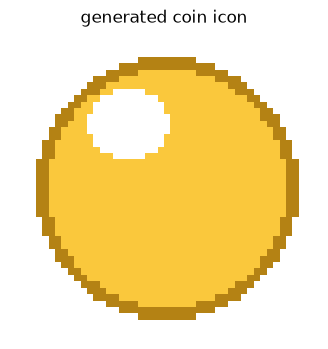

In [5]:
def make_coin_icon(size=48):
    """a simple 'coin' game icon - a filled circle, a darker outline, and a small highlight ellipse to fake a shiny look"""
    icon = Image.new("RGBA", (size, size), (0, 0, 0, 0))  # RGBA adds an alpha (transparency) channel - (0,0,0,0) = fully transparent background
    draw = ImageDraw.Draw(icon)
    margin = 4
    # the main coin body - a gold-ish filled circle with a darker gold outline around it
    draw.ellipse([margin, margin, size - margin, size - margin], fill=(250, 200, 60), outline=(180, 130, 20), width=2)
    # a small white-ish highlight near the top-left - this cheap trick is basically THE classic way to make any round game icon look shiny
    draw.ellipse([size * 0.25, size * 0.2, size * 0.5, size * 0.4], fill=(255, 255, 255))
    return icon


coin_icon = make_coin_icon()
show_image(coin_icon, title="generated coin icon")

## saving a generated image to disk (and cleaning up right after)
* `image.save("filename.png")` actually writes a real image file - this is how you would export generated game art for real use
* just like lesson 20 taught us with `plt.savefig()`, we save one here purely to prove it works, then immediately delete it again - we dont want to leave generated files lying around in the repo

In [6]:
import os

coin_icon.save("demo_coin.png")  # writes our generated coin icon to disk as a real PNG file
print("file exists on disk?", os.path.exists("demo_coin.png"))

os.remove("demo_coin.png")  # clean up immediately - we dont want to leave this generated file lying around in the repo
print("file exists after cleanup?", os.path.exists("demo_coin.png"))

file exists on disk? True
file exists after cleanup? False


## adding noise/variation to make a texture look less flat
* a perfectly flat, single-color tile looks fake/plastic - real-world materials always have tiny imperfections and variation
* a super simple fix: nudge every pixel's color by a small random amount - lets compare a "before" (flat, boring) and "after" (slightly noisy, more organic) tile side by side

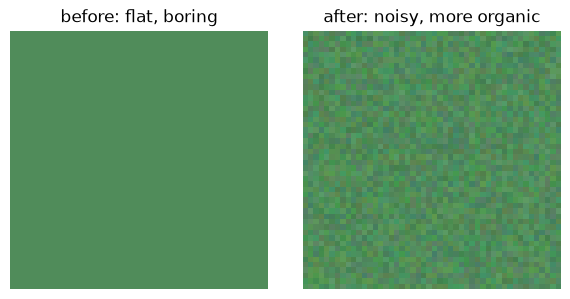

In [7]:
def make_flat_tile(size=48, color=(80, 140, 90)):
    """a perfectly flat, single-color tile - technically fine, but looks boring/artificial, nothing in the real world is this uniform"""
    return Image.new("RGB", (size, size), color=color)


def add_pixel_noise(image, amount=15):
    """returns a NEW image where every pixel gets a small random nudge on each color channel - breaks up the 'too perfect' flatness"""
    array = np.array(image).astype(int)  # cast to int first so we can safely add/subtract without wrapping around at the 0/255 boundary
    noise = np.random.randint(-amount, amount + 1, size=array.shape)  # one independent random nudge per pixel, per color channel
    noisy_array = np.clip(array + noise, 0, 255).astype(np.uint8)  # clip back into the valid 0-255 range, then back to uint8 for PIL to use
    return Image.fromarray(noisy_array)  # numpy array -> PIL Image, the reverse of np.array(image)


flat_tile = make_flat_tile()
noisy_tile = add_pixel_noise(flat_tile)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(np.array(flat_tile))
ax[0].set_title("before: flat, boring")
ax[0].axis("off")
ax[1].imshow(np.array(noisy_tile))
ax[1].set_title("after: noisy, more organic")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## generating a maze - the recursive backtracker algorithm
* this is a genuinely classic algorithm, used in tons of real roguelikes/dungeon crawlers: randomized depth-first-search carving out corridors from a solid block of walls
* it produces a "perfect" maze - exactly ONE path between any two floor cells, no loops, no isolated unreachable areas
* we represent the maze as a 2D numpy grid of `1` (wall) and `0` (floor) - width/height should be ODD numbers: even coordinates are "cells", the odd coordinates in between are the walls/passages connecting them

maze shape: (21, 21) (1 = wall, 0 = floor)


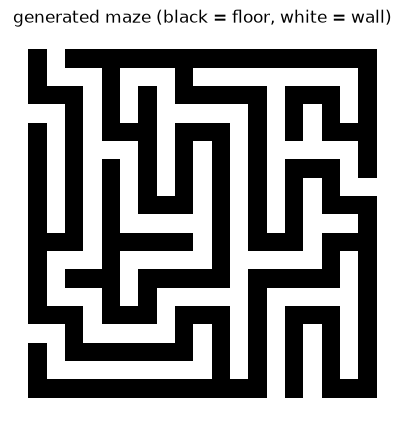

In [8]:
def generate_maze(width, height, seed=42):
    """recursive backtracker maze generator - carves a perfect maze into a width x height grid of 1s (wall) and 0s (floor)"""
    rng = random.Random(seed)  # our OWN random instance (not the global one) - keeps this function fully self-contained and reproducible on its own
    grid = np.ones((height, width), dtype=int)  # start completely solid/filled with walls (1 = wall, 0 = floor)

    def neighbor_cells(cy, cx):
        # potential next cells are always 2 steps away in one direction - we skip over the wall cell sitting exactly between them
        candidates = [(cy - 2, cx), (cy + 2, cx), (cy, cx - 2), (cy, cx + 2)]
        rng.shuffle(candidates)  # shuffling here is THE key ingredient - its what makes every generated maze different/random
        return candidates

    start = (1, 1)
    grid[start] = 0  # carve out our starting cell
    stack = [start]  # an explicit stack instead of true python recursion - avoids hitting pythons recursion limit on bigger mazes

    while stack:
        current_y, current_x = stack[-1]  # peek at the cell on top of the stack, without removing it yet
        unvisited = [
            (ny, nx) for ny, nx in neighbor_cells(current_y, current_x)
            if 0 <= ny < height and 0 <= nx < width and grid[ny, nx] == 1  # still inside the grid bounds AND still an uncarved wall cell
        ]
        if unvisited:
            next_y, next_x = unvisited[0]  # candidates were already shuffled above, so "first remaining" is effectively "random"
            wall_y, wall_x = (current_y + next_y) // 2, (current_x + next_x) // 2  # the wall cell sitting exactly between current and next
            grid[wall_y, wall_x] = 0  # knock down that wall...
            grid[next_y, next_x] = 0  # ...and carve out the new cell too
            stack.append((next_y, next_x))  # move "into" the new cell, keep exploring from there
        else:
            stack.pop()  # dead end - nowhere new to go, so backtrack to the previous cell and try ITS other unexplored neighbors instead

    return grid


maze = generate_maze(21, 21, seed=42)
print("maze shape:", maze.shape, "(1 = wall, 0 = floor)")

plt.figure(figsize=(5, 5))
plt.imshow(maze, cmap="gray")  # matplotlibs plain grayscale colormap: 0 -> black, 1 -> white, so floor/wall are instantly obvious
plt.title("generated maze (black = floor, white = wall)")
plt.axis("off")
plt.show()

## noise-based terrain generation (a simple "value noise")
* real games (Minecraft being the most famous example) generate entire terrains from **noise functions** - smooth, semi-random variation instead of pure random static
* we build a genuinely simple version by hand, no external noise library: start with a small grid of PURE random values, blow it up bigger, then smooth it so neighboring areas blend into hills instead of looking like TV static
* this is deliberately simplified to build intuition for the underlying IDEA, not meant to be a production-quality noise function (see the language comparison below for the real thing)

heightmap shape: (64, 64) min: 0.0 max: 1.0


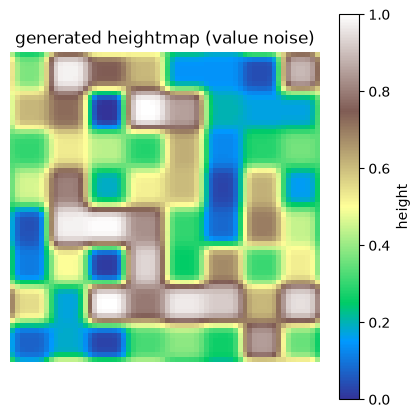

In [9]:
def generate_heightmap(coarse_size=8, upscale=8, seed=42):
    """builds a simple value-noise heightmap: a small grid of random 'control points', blown up bigger, then smoothed a few times"""
    rng = np.random.RandomState(seed)  # our own numpy random state - same reproducibility trick as the maze function above
    coarse = rng.rand(coarse_size, coarse_size)  # a small grid of random floats between 0.0 and 1.0 - these are our rough "control points"

    # np.kron repeats each coarse cell into an upscale x upscale block of IDENTICAL values - a cheap, simple way to blow the grid up bigger
    heightmap = np.kron(coarse, np.ones((upscale, upscale)))

    # a few smoothing passes - average every cell with its 4 direct neighbors, this blurs the hard block edges from kron into smoother hills
    for _ in range(3):
        # np.roll shifts the WHOLE array by one step in a direction - averaging 4 shifted copies with the original is a cheap, easy blur
        # (np.roll wraps around at the edges, so our terrain technically tiles/wraps - totally fine for a simple lesson like this one)
        heightmap = (
            heightmap
            + np.roll(heightmap, 1, axis=0) + np.roll(heightmap, -1, axis=0)
            + np.roll(heightmap, 1, axis=1) + np.roll(heightmap, -1, axis=1)
        ) / 5

    heightmap = (heightmap - heightmap.min()) / (heightmap.max() - heightmap.min())  # rescale back to a clean 0.0-1.0 range after smoothing
    return heightmap


heightmap = generate_heightmap()
print("heightmap shape:", heightmap.shape, "min:", round(heightmap.min(), 2), "max:", round(heightmap.max(), 2))

plt.figure(figsize=(5, 5))
plt.imshow(heightmap, cmap="terrain")  # matplotlibs "terrain" colormap - low values look watery/blue-green, high values look mountainous/white
plt.title("generated heightmap (value noise)")
plt.colorbar(label="height")
plt.axis("off")
plt.show()

## turning the heightmap into game-ready tile data
* a continuous heightmap of floats is nice to look at, but a game engine wants discrete TILE TYPES to actually build a map out of
* we threshold the heightmap into buckets: low height -> "water", medium -> "grass", high -> "mountain" - exactly the kind of tile grid the upcoming RPG lessons can build a world map on top of

a small corner of the tile map:
[['grass' 'grass' 'water' 'water' 'water' 'water']
 ['grass' 'grass' 'grass' 'grass' 'grass' 'grass']
 ['grass' 'grass' 'grass' 'grass' 'grass' 'grass']
 ['grass' 'grass' 'grass' 'grass' 'grass' 'grass']
 ['grass' 'grass' 'grass' 'grass' 'grass' 'grass']
 ['grass' 'grass' 'grass' 'grass' 'grass' 'grass']]
grass: 1467 tiles (36%)
mountain: 1362 tiles (33%)
water: 1267 tiles (31%)


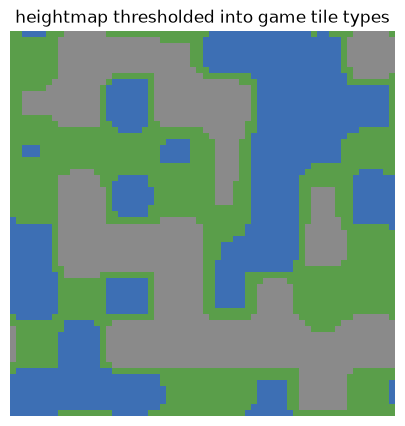

In [10]:
def heightmap_to_tiles(heightmap, water_max=0.3, grass_max=0.6):
    """turns a continuous heightmap into a grid of discrete game tile type strings - this is the game-ready output of this whole lesson"""
    tiles = np.empty(heightmap.shape, dtype=object)  # dtype=object lets a numpy array hold plain python strings instead of only numbers
    tiles[heightmap < water_max] = "water"
    tiles[(heightmap >= water_max) & (heightmap < grass_max)] = "grass"
    tiles[heightmap >= grass_max] = "mountain"
    return tiles


tile_map = heightmap_to_tiles(heightmap)
print("a small corner of the tile map:")
print(tile_map[:6, :6])

# a quick count of how many tiles of each type we ended up with, as a sanity check
unique_tiles, counts = np.unique(tile_map, return_counts=True)
for tile_type, count in zip(unique_tiles, counts):
    print(f"{tile_type}: {count} tiles ({count / tile_map.size:.0%})")

# for imshow() we need NUMBERS, not strings - so we map each tile type to a small integer id first
from matplotlib.colors import ListedColormap

tile_type_to_id = {"water": 0, "grass": 1, "mountain": 2}
tile_id_grid = np.vectorize(tile_type_to_id.get)(tile_map)  # applies the dict lookup to every cell in the array at once
tile_cmap = ListedColormap(["#3d6fb4", "#5a9e4a", "#8a8a8a"])  # water=blue, grass=green, mountain=gray - matching the ids above, in order

plt.figure(figsize=(5, 5))
plt.imshow(tile_id_grid, cmap=tile_cmap)
plt.title("heightmap thresholded into game tile types")
plt.axis("off")
plt.show()

## quick comparison to other languages
* procedural generation is a genuinely famous, language-agnostic game design technique, not a python-only trick - **Minecraft** (originally written in Java) generates its entire infinite world procedurally from noise functions very similar in spirit to what we built here, just far more sophisticated (real Perlin/Simplex noise, layered across multiple "octaves" of detail)
* **No Man's Sky** and **Spelunky** are two more famous examples of procedural-generation-heavy games, in completely different genres (space exploration vs a 2D platformer)
* the free, language-agnostic map editor **Tiled** (mentioned back in lesson 27's world) is often used to HAND-place a level on top of, or instead of, procedural generation - the two approaches are frequently combined in real games
* real production noise functions (Perlin, Simplex, OpenSimplex) exist as ready-made libraries in essentially every language: the `noise`/`opensimplex` packages in python, `SimplexNoise` built directly into many game engines (Godot, Unity, ...), and `noisejs` in JavaScript - we deliberately built a simplified version by hand in this lesson purely to understand the underlying IDEA (smooth, semi-random variation) rather than depend on an extra package

## Exercises
1. generate a new procedural texture of your own design using PIL (e.g. a simple striped or checkered pattern tile) and display it
2. add per-pixel color noise/variation to a flat-colored image of your own and show the before/after, side by side
3. generate a maze with a DIFFERENT random seed than the main example (seed=42) and visualize it, noting in a comment how the shape differs
4. change the water/grass/mountain thresholds on the heightmap, re-visualize the resulting tile map, and describe in a comment how the proportions of each tile type changed

In [11]:
# TODO: solve exercise 1 here (generate a new procedural texture, e.g. striped or checkered tile)


# TODO: solve exercise 2 here (add per-pixel noise to a flat-colored image, show before/after)


# TODO: solve exercise 3 here (generate a maze with a different seed than 42, visualize it)


# TODO: solve exercise 4 here (change the water/grass/mountain thresholds, re-visualize the tile map)

### sample solutions
* try the exercises above yourself first, only look here if you are stuck or want to compare your approach

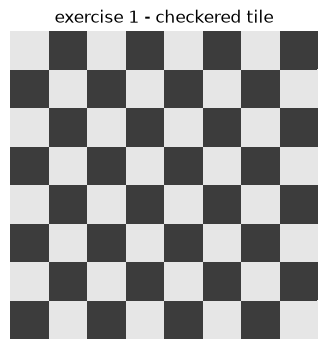

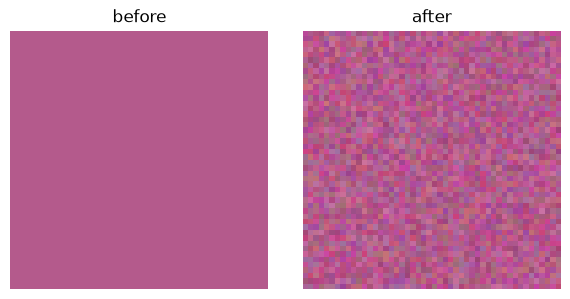

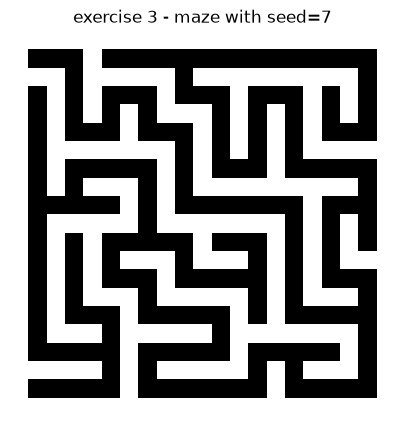

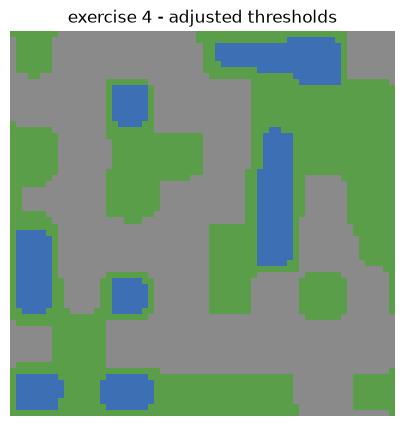

grass: 1594 tiles (39%)
mountain: 2005 tiles (49%)
water: 497 tiles (12%)


In [12]:
# sample solution 1 - a checkered pattern tile
def make_checker_tile(size=64, square=8, color_a=(230, 230, 230), color_b=(60, 60, 60)):
    tile = Image.new("RGB", (size, size))
    draw = ImageDraw.Draw(tile)
    for y in range(0, size, square):
        for x in range(0, size, square):
            is_even = ((x // square) + (y // square)) % 2 == 0  # the classic checkerboard trick: alternate based on row+column parity
            draw.rectangle([x, y, x + square - 1, y + square - 1], fill=color_a if is_even else color_b)
    return tile


checker_tile = make_checker_tile()
show_image(checker_tile, title="exercise 1 - checkered tile")


# sample solution 2 - noise on a flat colored image
exercise_flat = make_flat_tile(size=48, color=(180, 90, 140))  # a flat pink/purple tile this time, just to use a different color
exercise_noisy = add_pixel_noise(exercise_flat, amount=25)

fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(np.array(exercise_flat))
ax[0].set_title("before")
ax[0].axis("off")
ax[1].imshow(np.array(exercise_noisy))
ax[1].set_title("after")
ax[1].axis("off")
plt.tight_layout()
plt.show()


# sample solution 3 - a maze with a different seed
exercise_maze = generate_maze(21, 21, seed=7)  # different seed than the seed=42 we used for the main example above
plt.figure(figsize=(5, 5))
plt.imshow(exercise_maze, cmap="gray")
plt.title("exercise 3 - maze with seed=7")
plt.axis("off")
plt.show()
# comparing this to our seed=42 maze above: same algorithm, same size, but a totally different layout of corridors/dead ends -
# this is exactly WHY we always fix a seed explicitly - without it, every run (and every reader re-running this notebook) would see a different maze


# sample solution 4 - different water/grass/mountain thresholds
exercise_tiles = heightmap_to_tiles(heightmap, water_max=0.15, grass_max=0.45)  # much stricter cutoffs than the original 0.3 / 0.6
exercise_tile_ids = np.vectorize(tile_type_to_id.get)(exercise_tiles)

plt.figure(figsize=(5, 5))
plt.imshow(exercise_tile_ids, cmap=tile_cmap)
plt.title("exercise 4 - adjusted thresholds")
plt.axis("off")
plt.show()

exercise_unique, exercise_counts = np.unique(exercise_tiles, return_counts=True)
for tile_type, count in zip(exercise_unique, exercise_counts):
    print(f"{tile_type}: {count} tiles ({count / exercise_tiles.size:.0%})")
# lowering water_max and grass_max means FEWER cells qualify as "water" or "grass", so way more cells fall into whatever is left ("mountain") -
# in general: pushing a threshold DOWN shrinks the category below it and grows the category above it, since the total number of tiles never changes

* congratulation you finished this lesson

## what we learned
* WHY procedural generation matters for games - hand-making every sprite/texture/level doesnt scale, and code/randomness/algorithms can generate that content instead
* Pillow (`PIL.Image`, `PIL.ImageDraw`) basics: creating a blank image, drawing rectangles/ellipses/lines onto it, and building reusable "generator" functions for gradient tiles, brick wall tiles and a coin icon
* adding small per-pixel random noise to a flat texture to make it look less artificial/perfect
* the recursive backtracker maze algorithm - randomized depth-first-search carving a perfect maze (exactly one path between any two points) into a grid of walls/floors
* a simple hand-built "value noise" heightmap - a small random grid, upscaled with `np.kron`, then smoothed with a few `np.roll`-based blur passes
* thresholding a continuous heightmap into discrete GAME-READY tile types (water/grass/mountain), and visualizing both a heightmap (`cmap="terrain"`) and a discrete tile grid (a custom `ListedColormap`)
* real games (Minecraft, No Man's Sky, Spelunky) use these exact same ideas at a much larger scale, usually with real Perlin/Simplex noise libraries instead of our simplified hand-built version